Air Passenger Prediction using Time Series Analysis : ARIMA

Import libraries

In [212]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tabulate import tabulate

import warnings
warnings.filterwarnings("ignore")

Box–Jenkins method

The original model uses an iterative three-stage modeling approach:

Model identification and model selection: making sure that the variables are stationary, identifying seasonality in the dependent series (seasonally differencing it if necessary), and using plots of the autocorrelation (ACF) and partial autocorrelation (PACF) functions of the dependent time series to decide which (if any) autoregressive or moving average component should be used in the model.

Parameter estimation using computation algorithms to arrive at coefficients that best fit the selected ARIMA model. The most common methods use maximum likelihood estimation or non-linear least-squares estimation.

Statistical model checking by testing whether the estimated model conforms to the specifications of a stationary univariate process. In particular, the residuals should be independent of each other and constant in mean and variance over time. (Plotting the mean and variance of residuals over time and performing a Ljung–Box test or plotting autocorrelation and partial autocorrelation of the residuals are helpful to identify misspecification.) If the estimation is inadequate, we have to return to step one and attempt to build a better model.

In [213]:
# Load the dataset
df = pd.read_csv("/home/leonie/Downloads/TimeSeriesAnalysis/data/AirPassengers.csv", parse_dates=["Month"])
df.head()

## Month : time
## Passenger : Number of passengers

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [214]:
# Rename the passenger columns
df.rename(columns={"#Passengers":"Passengers"}, inplace=True)
df.head()

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [215]:
df.info()
# There is no missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [216]:
df.set_index("Month", inplace=True)

Model Identification

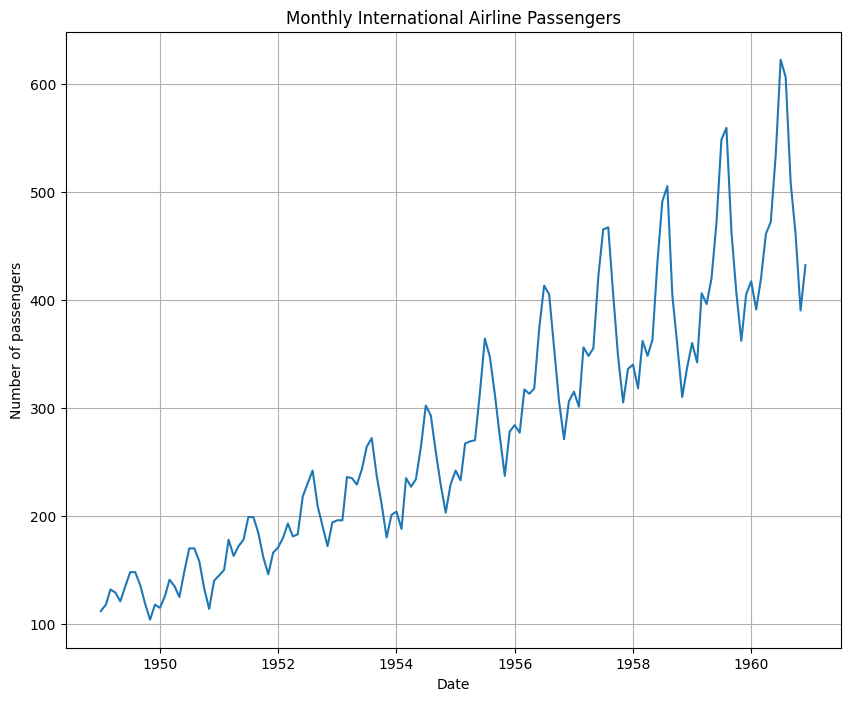

In [217]:
# Graphic representation
plt.figure(figsize=(10, 8))
plt.plot(df.index, df.Passengers)
plt.xlabel("Date")
plt.ylabel("Number of passengers")
plt.title("Monthly International Airline Passengers")
plt.grid(True)

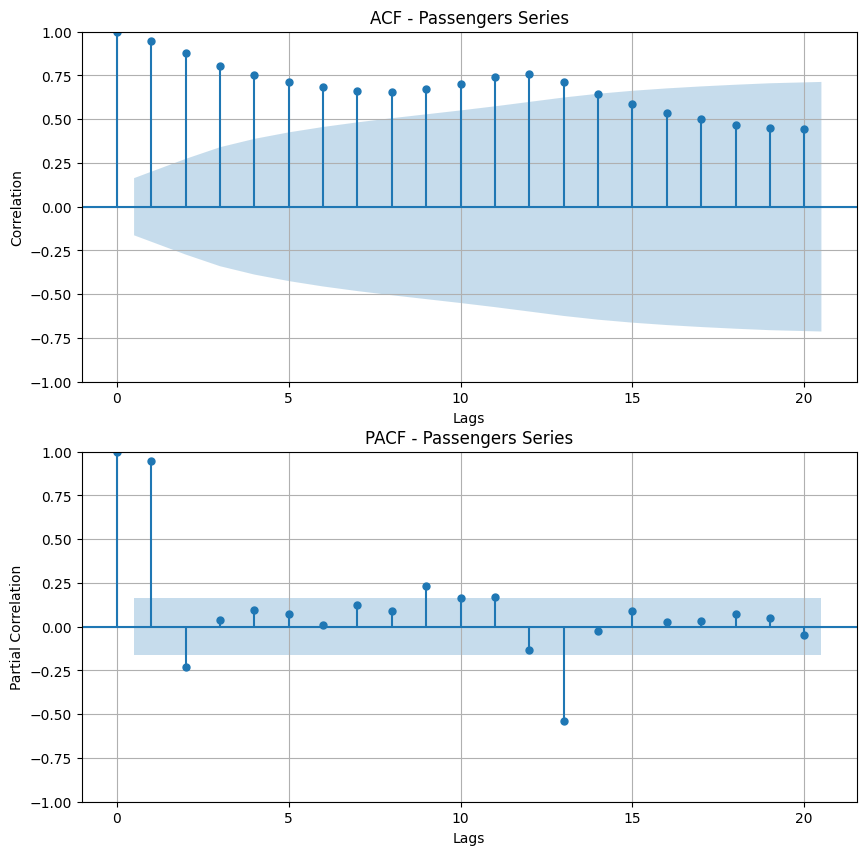

In [218]:
# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Plot the ACF graph
plot_acf(df["Passengers"], lags=20, ax=ax1)
ax1.set_xlabel("Lags")
ax1.set_ylabel("Correlation")
ax1.set_title("ACF - Passengers Series")
ax1.grid(True)

# Plot the PACF graph
plot_pacf(df["Passengers"], lags=20, ax=ax2)
ax2.set_xlabel("Lags")
ax2.set_ylabel("Partial Correlation")
ax2.set_title("PACF - Passengers Series")
ax2.grid(True)

In [219]:
# Statistical Tests to check the stationarity :  Augmented Dickey Fuller
result = adfuller(df)
table = [
    ["ADF Statistic", result[0]],
    ["P-value", result[1]],
    ["Stationarity", "Yes" if result[1] < 0.05 else "No"]
]

print(tabulate(table, headers=["Metrics", "Value"], tablefmt="github"))

| Metrics       | Value              |
|---------------|--------------------|
| ADF Statistic | 0.8153688792060498 |
| P-value       | 0.991880243437641  |
| Stationarity  | No                 |


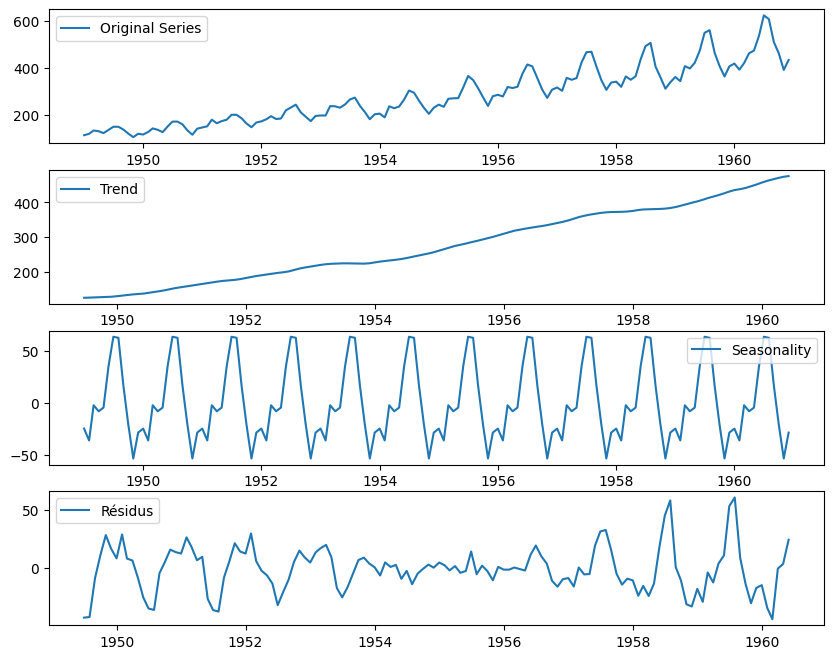

In [220]:
# Decompose the time series into its componants
# seasonal_decompose : a function from the statsmodels library used 
#to break a time series into three distinct components: Trend, Seasonality, and Residual (noise)
decomposition = seasonal_decompose(df["Passengers"], model="additive")

# Trend component
trend = decomposition.trend
# Seasonality component
seasonality = decomposition.seasonal
# Noise
noise = decomposition.resid

# Create subplots
plt.figure(figsize=(10, 8))

# The original dataset
plt.subplot(4, 1, 1)
plt.plot(df["Passengers"], label="Original Series")
plt.legend(loc="best")

# Trend
plt.subplot(4, 1, 2)
plt.plot(trend, label="Trend")
plt.legend(loc="best")

# Seaonality
plt.subplot(4, 1, 3)
plt.plot(seasonality, label="Seasonality")
plt.legend(loc="best")

# Noise
plt.subplot(4, 1, 4)
plt.plot(noise, label="Résidus")
plt.legend(loc="best")

From the ACF plotting, we notice a slow decay across many lags which is a typical indication of a non-stationary series. As passengers times series is not stationary, we will differentiate to make it stationary, although the PACF shows a sharp cutoff after the second lag.

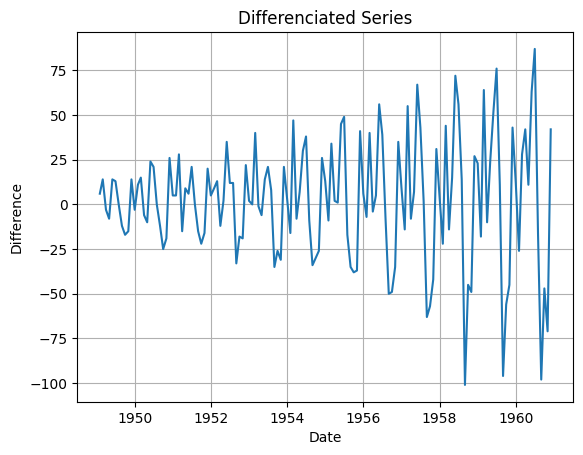

In [221]:
# Differenciation
differenciated = df["Passengers"].diff().dropna()

# Plot the series
plt.plot(differenciated)
plt.xlabel("Date")
plt.ylabel("Difference")
plt.title("Differenciated Series")
plt.grid(True)

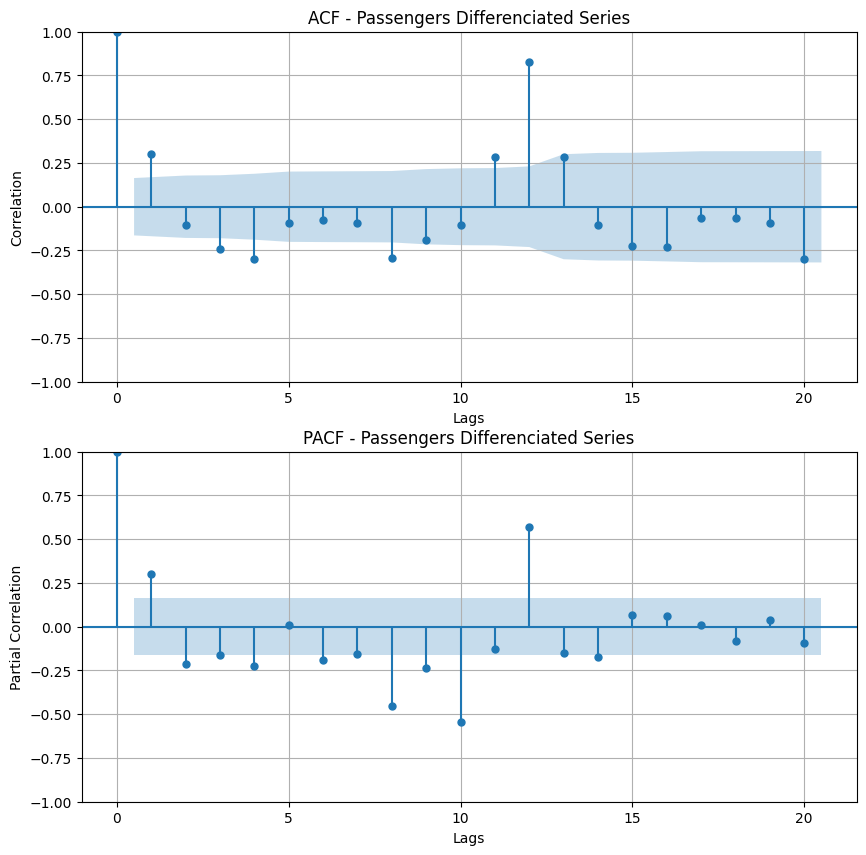

In [222]:
# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# ACF 
plot_acf(differenciated, lags=20, ax=ax1)
ax1.set_title ("ACF - Passengers Differenciated Series")
ax1.set_xlabel("Lags")
ax1.set_ylabel("Correlation")
ax1.grid(True)

# PACF
plot_pacf(differenciated, lags=20, ax=ax2)
ax2.set_title("PACF - Passengers Differenciated Series")
ax2.set_xlabel("Lags")
ax2.set_ylabel("Partial Correlation")
ax2.grid(True)

In [223]:
# Dickey Fuller Test
result_dif = adfuller(differenciated)
table_dif = [
    ["ADF Statistic", result_dif[0]],
    ["P-value", result_dif[1]],
    ["Stationarity", "Yes" if result_dif[1] < 0.05 else "No"]
]

print(tabulate(table_dif, headers=["Metrics", "Value"], tablefmt="github"))

| Metrics       | Value               |
|---------------|---------------------|
| ADF Statistic | -2.8292668241700047 |
| P-value       | 0.05421329028382478 |
| Stationarity  | No                  |


Parameters estimation

In [224]:
# Parameters from the ACF PACF, and the differenciation
p=2 # From PACF
q=1 # From ACF
d=1 # From differenciation

In [225]:
# Split the data into train and test dataset
train = df[:-15]
test = df[-15:]

Model Building

In [226]:
# Instantiate the model ARIMA(2, 1, 1)
model = ARIMA(train, order=(2, 1, 1))

# Train the model
model_fit = model.fit()

# Show the model summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  129
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -604.753
Date:                Tue, 31 Mar 2026   AIC                           1217.507
Time:                        22:08:23   BIC                           1228.915
Sample:                    01-01-1949   HQIC                          1222.142
                         - 09-01-1959                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0810      0.105     10.263      0.000       0.875       1.287
ar.L2         -0.4722      0.102     -4.641      0.000      -0.672      -0.273
ma.L1         -0.8445      0.094     -8.981      0.0

Statistical Model Checking

According to the diagnostic results of the trained model, several statistical test were conducted on the residuals to access the model adequacy. 
First, the Ljung-Box test gives a p-value greater than 0.05, indicating that the residuals are independent and do not exhibit autocorrelation.
Second, the heteroskedasticity test alo produces a p-value less than 0.05, implying the residuals do not have constant mean and variance.
Finally, the Jarque-Bera test results in a p-value greater that 0.05, indicating that the residuals are normally distributed.
Overall, these results suggest that the model satisfies the key assumptions, and so, can be considered statistically adequate for forecasting the number of air passenger.

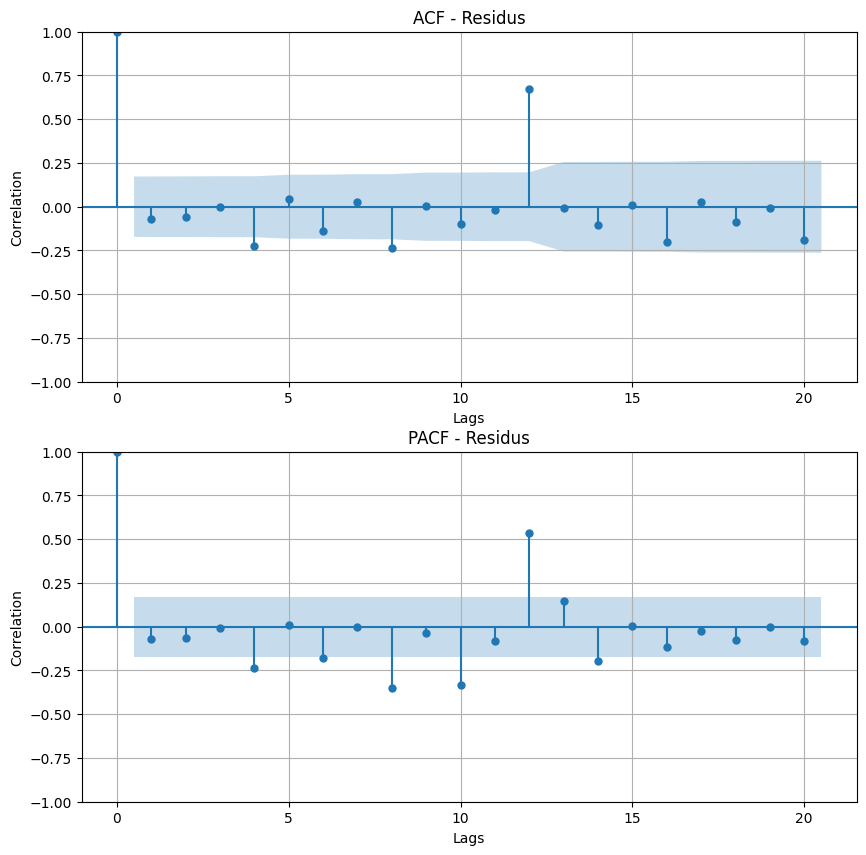

In [227]:
# Graphics representation of residus
residus = model_fit.resid

# Create subplots
fig, (ax3, ax4) = plt.subplots(2, 1, figsize=(10, 10))

# ACF - Residus
plot_acf(residus, lags=20, ax=ax3)
ax3.set_xlabel("Lags")
ax3.set_ylabel("Correlation")
ax3.set_title("ACF - Residus")
ax3.grid(True)

# PACF - Residus
plot_pacf(residus, lags=20, ax=ax4)
ax4.set_xlabel("Lags")
ax4.set_ylabel("Correlation")
ax4.set_title("PACF - Residus")
ax4.grid(True)

In [228]:
# Make prediction on the train dataset
train_pred = model_fit.predict(start=train.index[0], end=train.index[-1])
# Make prediction on the test dataset
test_pred = model_fit.predict(start=test.index[0], end=test.index[-1])

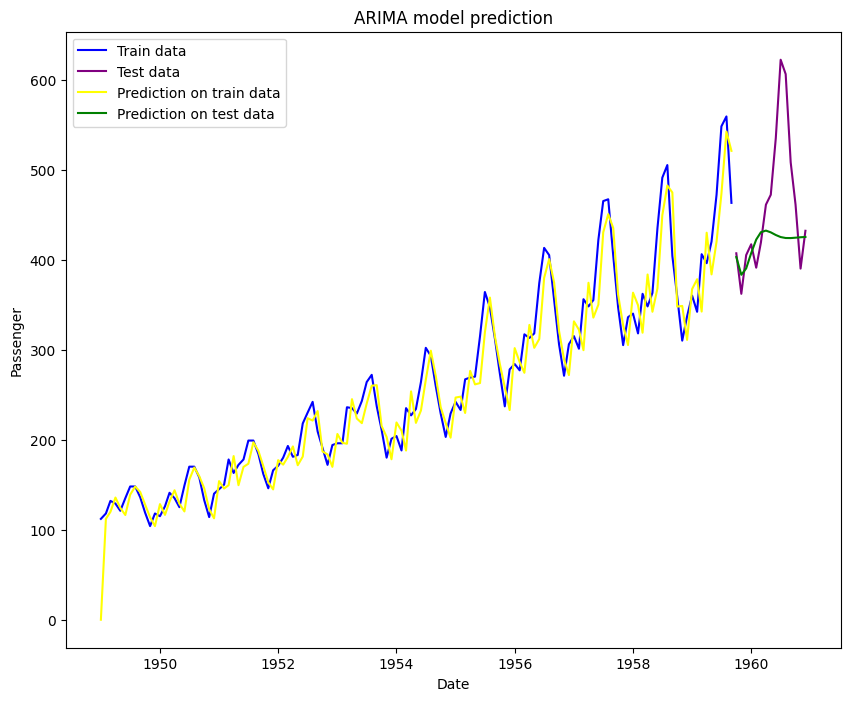

In [229]:
plt.figure(figsize=(10,8))

plt.plot(train.index, train.values, label="Train data", color="blue")
plt.plot(test.index, test.values, label="Test data", color="purple")
plt.plot(train_pred.index, train_pred.values, label="Prediction on train data", color="yellow")
plt.plot(test_pred.index, test_pred.values, label="Prediction on test data", color="green")

plt.xlabel("Date")
plt.ylabel("Passenger")
plt.title("ARIMA model prediction")
plt.legend(loc="best")
plt.show()

In [230]:
# Model performance on the train data
train_mae = mean_absolute_error(train, train_pred)
train_mse = mean_squared_error(train, train_pred)

# Model performance on the test data
test_mae = mean_absolute_error(test, test_pred)
test_mse = mean_squared_error(test, test_pred)

metrics = pd.DataFrame({"Metrics": ["MAE", "MSE"],"Train Data": [train_mae, train_mse],
                      "Test Data": [test_mae, test_mse]})
metrics

,Metrics,Train Data,Test Data
0,MAE,22.183944,54.144213
1,MSE,830.835014,6510.318943


These metrics show that the model is not performing well.

Hyperparameter Tuning

In [231]:
max_d = 1
max_p = [1, 2, 3, 4]
max_q = [1, 2, 3, 4]

orders = []
train_mae_list = []
test_mae_list = []
aic = []
bic = []
for p in max_p:
    for q in max_q:
        try:
            # Train the model
            forecaster = ARIMA(train, order=(p, d, q))
            forecaster_fit = forecaster.fit()

            # Predict using each model
            train_pred = forecaster_fit.predict(start=train.index[0], end=train.index[-1])
            test_pred = forecaster_fit.predict(start=test.index[0], end=test.index[-1])

            # Compute the mean absolute error and add it to the list
            train_mae = mean_absolute_error(train, train_pred)
            test_mae = mean_absolute_error(test, test_pred)
                
            orders.append((p, d, q))
            train_mae_list.append(train_mae)
            test_mae_list.append(test_mae)
            aic.append(forecaster_fit.aic)
            bic.append(forecaster_fit.bic)
        except:
            continue


result = pd.DataFrame({
    "Orders":orders,
    "Train MAE": train_mae_list,
    "Test MAE": test_mae_list,
    "AIC": aic,
    "BIC":bic
})

In [232]:
result

,Orders,Train MAE,Test MAE,AIC,BIC
0,"(1, 1, 1)",22.900190,59.298165,1223.716709,1232.272800
1,"(1, 1, 2)",22.940463,56.899313,1221.685393,1233.093514
2,"(1, 1, 3)",22.937603,57.458449,1223.614258,1237.874410
3,"(1, 1, 4)",19.638201,61.323825,1202.119177,1219.231358
4,"(2, 1, 1)",22.183944,54.144213,1217.506835,1228.914956
5,"(2, 1, 2)",19.943855,41.201784,1195.428971,1209.689122
6,"(2, 1, 3)",22.043040,57.958666,1217.854246,1234.966427
7,"(2, 1, 4)",19.025901,54.207052,1195.540599,1215.504811
8,"(3, 1, 1)",21.927529,54.623465,1219.009645,1233.269796
9,"(3, 1, 2)",21.825281,53.238521,1211.998901,1229.111082


The best model is the one which has the lower mae = 18.02. Then the one which has the order : (4, 1, 4).

In [243]:
best = ARIMA(train, order=(4, 1, 4))
best_fit = best.fit()
print(best_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  129
Model:                 ARIMA(4, 1, 4)   Log Likelihood                -583.630
Date:                Tue, 31 Mar 2026   AIC                           1185.260
Time:                        22:15:21   BIC                           1210.928
Sample:                    01-01-1949   HQIC                          1195.689
                         - 09-01-1959                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0538      0.118      0.457      0.647      -0.177       0.284
ar.L2          0.9622      0.107      9.024      0.000       0.753       1.171
ar.L3         -0.1092      0.089     -1.233      0.2

In [241]:
residus = best_fit.resid

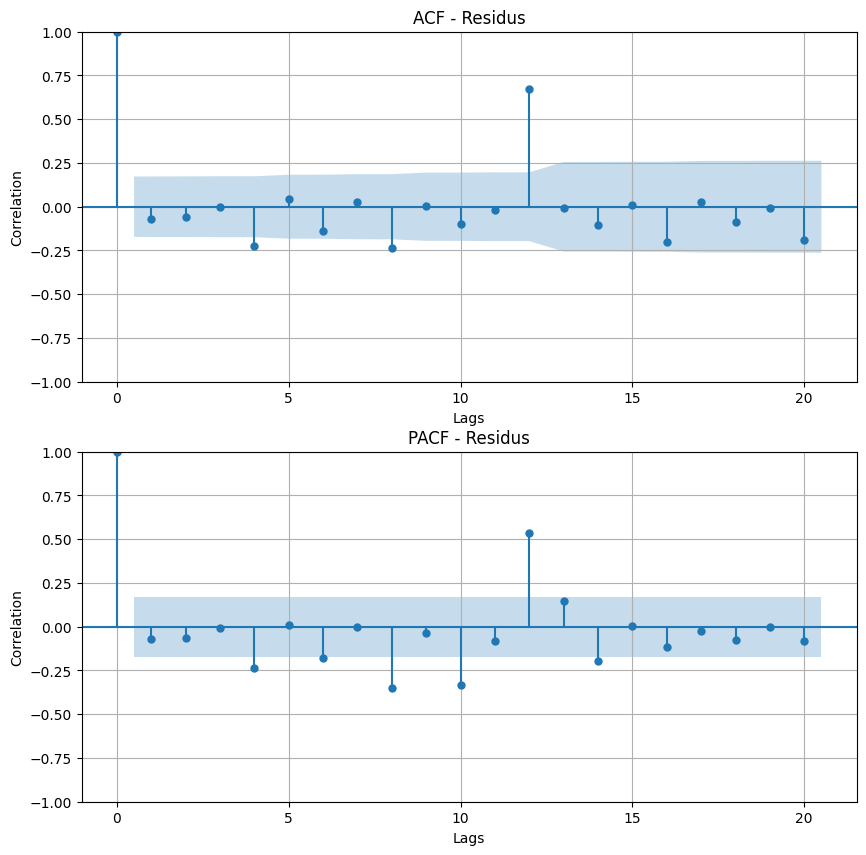

In [244]:
# Graphics representation of residus
residus = model_fit.resid

# Create subplots
fig, (ax3, ax4) = plt.subplots(2, 1, figsize=(10, 10))

# ACF - Residus
plot_acf(residus, lags=20, ax=ax3)
ax3.set_xlabel("Lags")
ax3.set_ylabel("Correlation")
ax3.set_title("ACF - Residus")
ax3.grid(True)

# PACF - Residus
plot_pacf(residus, lags=20, ax=ax4)
ax4.set_xlabel("Lags")
ax4.set_ylabel("Correlation")
ax4.set_title("PACF - Residus")
ax4.grid(True)

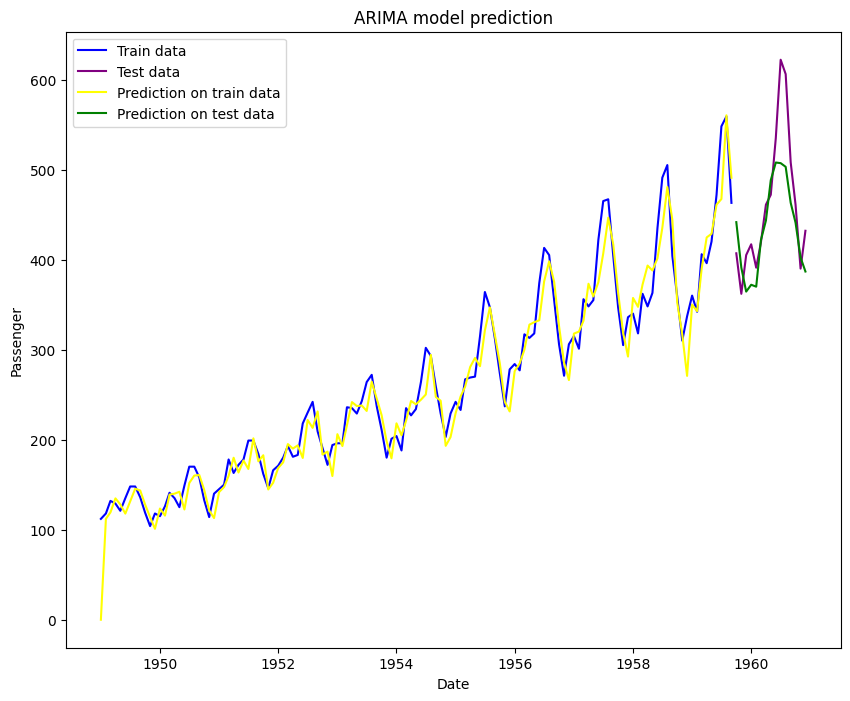

In [245]:
# Make prediction on the train dataset
train_pred = best_fit.predict(start=train.index[0], end=train.index[-1])
# Make prediction on the test dataset
test_pred = best_fit.predict(start=test.index[0], end=test.index[-1])


plt.figure(figsize=(10,8))

plt.plot(train.index, train.values, label="Train data", color="blue")
plt.plot(test.index, test.values, label="Test data", color="purple")
plt.plot(train_pred.index, train_pred.values, label="Prediction on train data", color="yellow")
plt.plot(test_pred.index, test_pred.values, label="Prediction on test data", color="green")

plt.xlabel("Date")
plt.ylabel("Passenger")
plt.title("ARIMA model prediction")
plt.legend(loc="best")
plt.show()

In [246]:
# Model performance on the train data
train_mae = mean_absolute_error(train, train_pred)
train_mse = mean_squared_error(train, train_pred)

# Model performance on the test data
test_mae = mean_absolute_error(test, test_pred)
test_mse = mean_squared_error(test, test_pred)

metrics = pd.DataFrame({"Metrics": ["MAE", "MSE"],"Train Data": [train_mae, train_mse],
                      "Test Data": [test_mae, test_mse]})
metrics

,Metrics,Train Data,Test Data
0,MAE,18.027806,38.286409
1,MSE,604.999207,2392.614777
